# Spoken Wiki attentional word recognition pilot task results

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



### Import human data

In [3]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition/data')
!ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("*.json"))


# import vocab dict for matching audio & responses 
# word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# # ix_to_word_map = {v:k for k,v in class_map.items()}
# class_map = word_and_speaker_encodings['word_idx_to_word']

index.html			    subj_5e380457679e67000c56b02f.json
old_cv_data			    subj_5eee77689e63ac330681ffe9.json
subj_5a8185b8aa46dd00016b80d6.json  subj_5f2f2e85c14511319b159fff.json
subj_5b5e0e86902ad10001cfcc59.json  subj_6229ea04db7c5f22b18c678d.json
subj_5c26ac6163e1d8000103824f.json  subj_6472ec9d6898fb5a55efa348.json
subj_5d11067c2016b10019c043e9.json


In [4]:
eg_part_data = json.load(open(human_fnames[0], 'r'))
eg_df = pd.DataFrame.from_records(eg_part_data)

In [6]:
## Get all subject data into one df for analysis
def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df


dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)
expmnt_trial_str = "dictionary-text"

subj_5a8185b8aa46dd00016b80d6 success True
subj_5d11067c2016b10019c043e9 success True
Unterminated string starting at: line 1 column 454384 (char 454383)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition/data/subj_5e380457679e67000c56b02f.json
subj_6229ea04db7c5f22b18c678d success True
subj_5f2f2e85c14511319b159fff success True
subj_5c26ac6163e1d8000103824f success True
subj_6472ec9d6898fb5a55efa348 success True
subj_5b5e0e86902ad10001cfcc59 success True
subj_5eee77689e63ac330681ffe9 success True


In [22]:
results_df.head()

,success,timeout,failed_images,failed_audio,failed_video,trial_type,trial_index,time_elapsed,internal_node_id,output_filename,...,response_str,catch_trial,correct_response,trial_num,correct,n_correct,n_incorrect,snr,condition,accuracy
0,True,False,[],[],[],preload,0,219,0.0-0.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,0
1,NaN,NaN,NaN,NaN,NaN,instructions,1,52934,0.0-1.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,0
2,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,2,63661,0.0-3.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,0
3,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,3,78615,0.0-4.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,0
4,NaN,NaN,NaN,NaN,NaN,survey-text,4,86654,0.0-5.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,0


In [20]:
# results_df[results_df.trial_type == "dictionary-text"] # only with rresponses 

In [23]:
results_df.columns

Index(['success', 'timeout', 'failed_images', 'failed_audio', 'failed_video',
       'trial_type', 'trial_index', 'time_elapsed', 'internal_node_id',
       'output_filename', 'id_random', 'id_study', 'id_subject', 'id_session',
       'id_version', 'hc_passed', 'view_history', 'rt', 'response',
       'question_order', 'stimulus', 'stim_type', 'hc_answer', 'hc_correct',
       'response_str', 'catch_trial', 'correct_response', 'trial_num',
       'correct', 'n_correct', 'n_incorrect', 'snr', 'condition', 'accuracy'],
      dtype='object')

In [29]:
results_df = results_df[results_df.hc_passed == True]

In [107]:
stim_cond_map

{'condition_00': ('background_musdb18hq', -9),
 'condition_01': ('background_musdb18hq', -6),
 'condition_02': ('background_musdb18hq', -3),
 'condition_03': ('background_musdb18hq', 0),
 'condition_04': ('background_musdb18hq', 3),
 'condition_05': ('background_cv08talkerbabble', -9),
 'condition_06': ('background_cv08talkerbabble', -6),
 'condition_07': ('background_cv08talkerbabble', -3),
 'condition_08': ('background_cv08talkerbabble', 0),
 'condition_09': ('background_cv08talkerbabble', 3),
 'condition_10': ('background_issnstationary', -9),
 'condition_11': ('background_issnstationary', -6),
 'condition_12': ('background_issnstationary', -3),
 'condition_13': ('background_issnstationary', 0),
 'condition_14': ('background_issnstationary', 3),
 'condition_15': ('background_issnfestenplomp', -9),
 'condition_16': ('background_issnfestenplomp', -6),
 'condition_17': ('background_issnfestenplomp', -3),
 'condition_18': ('background_issnfestenplomp', 0),
 'condition_19': ('background_

In [78]:
## Map wav str to stim_type using condition dict
import re

map_path = Path('/om2/user/imgriff/projects/Auditory-Attention/human_saddler_attn_expmt_cond_map.pkl')
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)

stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}
# stim_cond_map



def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    condition, snr = None,  None 
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        # print(stim_str)
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            condition, snr = stim_cond_map[cond_str]
        elif 'catch' in stim_str:
            condition = 'catch_trial'
            snr = np.inf
    return snr, condition


results_df['snr'], results_df['condition'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))

/tmp/ipykernel_6946/2855374519.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_df['snr'], results_df['condition'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))


In [79]:
results_df.head()

,success,timeout,failed_images,failed_audio,failed_video,trial_type,trial_index,time_elapsed,internal_node_id,output_filename,...,response_str,catch_trial,correct_response,trial_num,correct,n_correct,n_incorrect,snr,condition,accuracy
0,True,False,[],[],[],preload,0,219,0.0-0.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0
1,NaN,NaN,NaN,NaN,NaN,instructions,1,52934,0.0-1.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0
2,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,2,63661,0.0-3.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0
3,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,3,78615,0.0-4.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0
4,NaN,NaN,NaN,NaN,NaN,survey-text,4,86654,0.0-5.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0


In [80]:
results_df.columns

Index(['success', 'timeout', 'failed_images', 'failed_audio', 'failed_video',
       'trial_type', 'trial_index', 'time_elapsed', 'internal_node_id',
       'output_filename', 'id_random', 'id_study', 'id_subject', 'id_session',
       'id_version', 'hc_passed', 'view_history', 'rt', 'response',
       'question_order', 'stimulus', 'stim_type', 'hc_answer', 'hc_correct',
       'response_str', 'catch_trial', 'correct_response', 'trial_num',
       'correct', 'n_correct', 'n_incorrect', 'snr', 'condition', 'accuracy'],
      dtype='object')

In [81]:
results_df.trial_type.unique()

array(['preload', 'instructions', 'survey-multi-choice', 'survey-text',
       'html-button-response', 'audio-button-response',
       'audio-keyboard-response', 'dictionary-text',
       'html-keyboard-response'], dtype=object)

In [82]:
trial_results = results_df[results_df.trial_type == "dictionary-text"]

In [83]:
trial_results.condition.unique()

array(['background_cv08talkerbabble', '4-talker',
       'background_issnstationary', 'background_issnfestenplomp',
       '1-talker', 'catch_trial', 'background_audioset',
       'background_musdb18hq', 'background_ieeeaaspcasa'], dtype=object)

In [84]:
trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()
catch_trial_particiapnt_performance

/tmp/ipykernel_6946/798094779.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')


id_subject
5a8185b8aa46dd00016b80d6    0.916667
5b5e0e86902ad10001cfcc59    1.000000
5c26ac6163e1d8000103824f    1.000000
5f2f2e85c14511319b159fff    1.000000
6229ea04db7c5f22b18c678d    1.000000
Name: accuracy, dtype: float64

In [85]:
print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 10/12].index
print("N good participants ", len(good_participants))

good_results = results_df[results_df.id_subject.isin(good_participants)]

N total participants  5
N good participants  5


In [115]:
good_results.condition.value_counts()

background_issnstationary      360
background_issnfestenplomp     352
background_audioset            350
1-talker                       348
background_ieeeaaspcasa        346
background_cv08talkerbabble    344
background_musdb18hq           334
4-talker                       278
catch_trial                     90
Name: condition, dtype: int64

In [86]:
# get trial data excluding catch trials 
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response_str.isna())]


part_summary_df = (analysis_df.groupby(["snr", 'id_subject', "condition"])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())



background_audioset            25
1-talker                       24
background_ieeeaaspcasa        24
background_issnstationary      23
background_musdb18hq           23
background_cv08talkerbabble    22
background_issnfestenplomp     22
4-talker                       19
catch_trial                     5
Name: condition, dtype: int64

In [87]:
part_summary_df

,snr,id_subject,condition,mean
0,-9.0,5a8185b8aa46dd00016b80d6,1-talker,0.300000
1,-9.0,5a8185b8aa46dd00016b80d6,4-talker,0.000000
2,-9.0,5a8185b8aa46dd00016b80d6,background_audioset,0.444444
3,-9.0,5a8185b8aa46dd00016b80d6,background_cv08talkerbabble,0.111111
4,-9.0,5a8185b8aa46dd00016b80d6,background_ieeeaaspcasa,0.000000
...,...,...,...,...
182,inf,5a8185b8aa46dd00016b80d6,catch_trial,0.916667
183,inf,5b5e0e86902ad10001cfcc59,catch_trial,1.000000
184,inf,5c26ac6163e1d8000103824f,catch_trial,1.000000
185,inf,5f2f2e85c14511319b159fff,catch_trial,1.000000


In [65]:
# part_summary_df = part_summary_df[part_summary_df.jspsych_id != 'vgbrx2o3mb']

In [88]:
part_summary_df

,snr,id_subject,condition,mean
0,-9.0,5a8185b8aa46dd00016b80d6,1-talker,0.300000
1,-9.0,5a8185b8aa46dd00016b80d6,4-talker,0.000000
2,-9.0,5a8185b8aa46dd00016b80d6,background_audioset,0.444444
3,-9.0,5a8185b8aa46dd00016b80d6,background_cv08talkerbabble,0.111111
4,-9.0,5a8185b8aa46dd00016b80d6,background_ieeeaaspcasa,0.000000
...,...,...,...,...
182,inf,5a8185b8aa46dd00016b80d6,catch_trial,0.916667
183,inf,5b5e0e86902ad10001cfcc59,catch_trial,1.000000
184,inf,5c26ac6163e1d8000103824f,catch_trial,1.000000
185,inf,5f2f2e85c14511319b159fff,catch_trial,1.000000


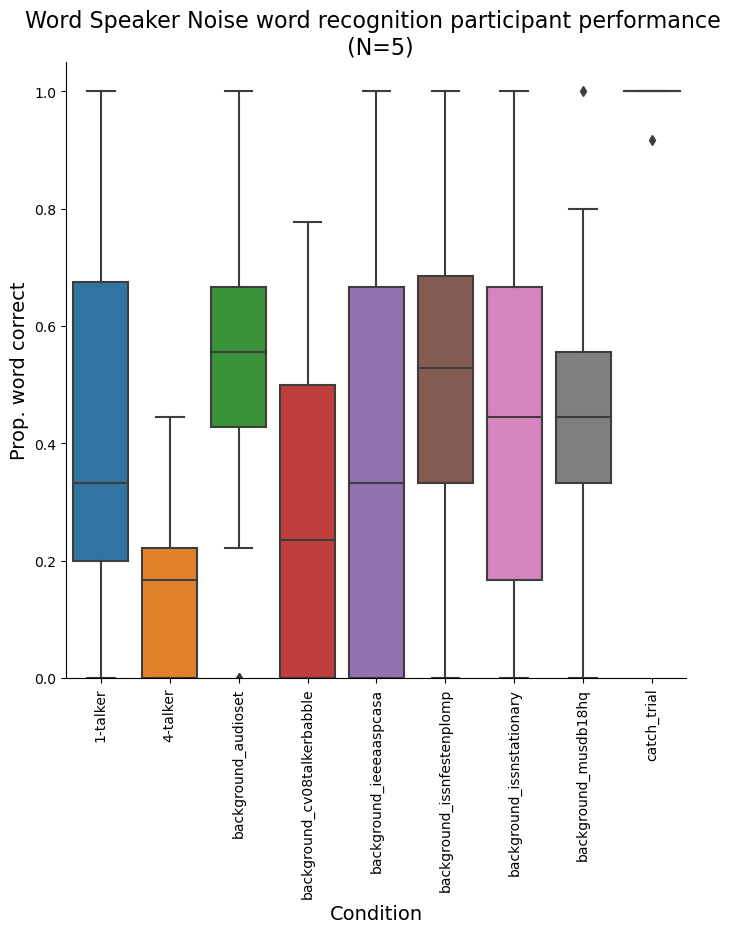

In [96]:
fontsize=14
n_participants = part_summary_df.id_subject.unique().shape[0]
fig, axs = plt.subplots(1, figsize=(8,8))

conds = part_summary_df.condition.unique()# order = ['clean', 'stationary_noise', 'natural_scene']
p = sns.boxplot( data=part_summary_df, x="condition",
                   y="mean",  #error='sem',
                   order=conds,
                  #capsize=0.1,
                   ax=axs)

sns.despine()
plt.ylim(0,1.05)
p.set_title(f"Word Speaker Noise word recognition participant performance \n (N={n_participants})",
                 fontsize=fontsize + 2)
p.set_xlabel("Condition",fontsize=fontsize)
p.set_ylabel("Prop. word correct", fontsize=fontsize)


p.set_xticklabels(labels=conds, rotation=90, size=10);



(0.0, 1.0)

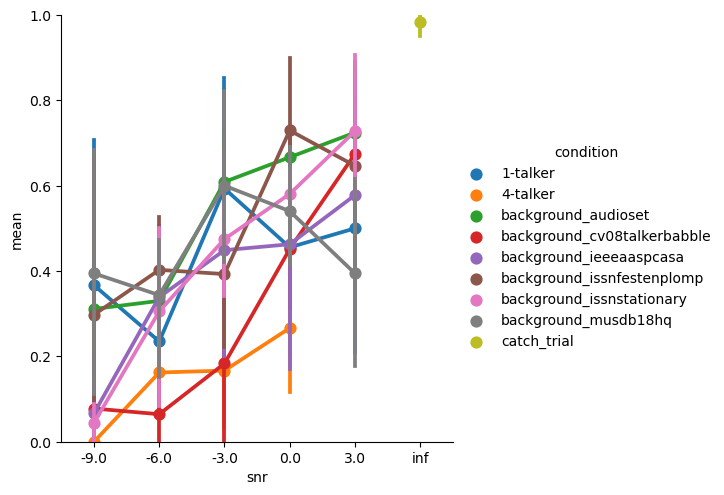

In [106]:
fontsize=14
n_participants = part_summary_df.id_subject.unique().shape[0]
# fig, axs = plt.subplots(1, figsize=(8,8))


conds = part_summary_df.condition.unique()
p = sns.catplot( kind='point',data=part_summary_df, x="snr",
                   y="mean",  hue='condition',
                #    linestyles="None",
                #    palette=["tab:blue", "tab:orange", "tab:green"],
                   )

sns.despine()
plt.ylim(0,1)
# axs.set_title(f"Word Speaker Noise word recognition participant performance \n (N={n_participants})",
#                  fontsize=fontsize + 2)
# axs.set_xlabel("Condition",fontsize=fontsize)
# axs.set_ylabel("Prop. word correct", fontsize=fontsize)

# p.set_xticklabels(labels=conds, rotation=0, size=fontsize)



In [109]:
part_summary_df.condition.value_counts()

background_audioset            25
1-talker                       24
background_ieeeaaspcasa        24
background_issnstationary      23
background_musdb18hq           23
background_cv08talkerbabble    22
background_issnfestenplomp     22
4-talker                       19
catch_trial                     5
Name: condition, dtype: int64